In [28]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import os

In [3]:
# Connectin to the database
DB_username = os.getenv("DHW_Username")
DB_password = os.getenv("DHW_Password")
DB_Server = os.getenv('DB_SERVER')

In [4]:
# step 1 databse connection 
# Input details for the SQL database
DB_TYPE = "mssql"
DB_USER = DB_username
DB_PWD = DB_password
DB_SERVER = DB_Server
DB_PORT = "1433"
DB_NAME = "PBI"
DB_DRIVER = "SQL Server"
# Connect to the database
conn_string = '{}://{}:{}@{}:{}/{}?driver={}'.format(DB_TYPE, DB_USER, DB_PWD, DB_SERVER, DB_PORT, DB_NAME, DB_DRIVER)
from sqlalchemy import create_engine
engine = create_engine(conn_string)
# Open a connection
conn = engine.connect()

In [5]:
# Read recent spend data
sql = """SELECT "CustomerURN", "CustomerRegion", "CustomerPostCode", "Sector", "SubSector", "SupplierName", "SupplierPostCode", "Category", "SubCategory", "FrameworkNumber", "FrameworkName", "LotNumber", "LotName", "FYMonthKey", "FinancialYear", "SpendType" FROM SpendAggregated"""
df = pd.read_sql(sql, conn)
print(df.head(10))

# 

   CustomerURN CustomerRegion CustomerPostCode                    Sector  \
0   10003768.0                         EH1 3XD  Devolved Administrations   
1   10002374.0                        SO30 2RA          Local Government   
2   10576707.0                        BS15 8AA                 Education   
3   10008639.0                          B1 1RN        Central Government   
4   10007226.0                         NW1 7QY                    Health   
5   10002941.0                         CT1 1YW          Local Government   
6   10021765.0                         EH5 2PW  Devolved Administrations   
7   10010068.0                         SW3 6NP                    Health   
8   10005047.0                         TA1 4DY          Local Government   
9   10007368.0                        PE28 4YE          Local Government   

  SubSector                              SupplierName SupplierPostCode  \
0      None            EDGE TESTING SOLUTIONS LIMITED           G1 2PF   
1      None    

In [16]:
df_LastFYYear = df.loc[df['FinancialYear']=='2023/24', :]
print(df.shape)
print(df_LastFYYear.shape)

(4553342, 16)
(543330, 16)


In [25]:
df_LastFYYear_Customer = df_LastFYYear[['CustomerURN', 'Sector']].groupby(by='CustomerURN').count()

In [26]:
print(df_LastFYYear_Customer)

             Sector
CustomerURN        
0.0              25
990100.0         12
990200.0         12
990500.0         28
990600.0         15
...             ...
10610110.0        2
10610203.0        2
10610206.0       15
10610346.0       12
10610347.0       12

[21354 rows x 1 columns]


(0.0, 10.0)

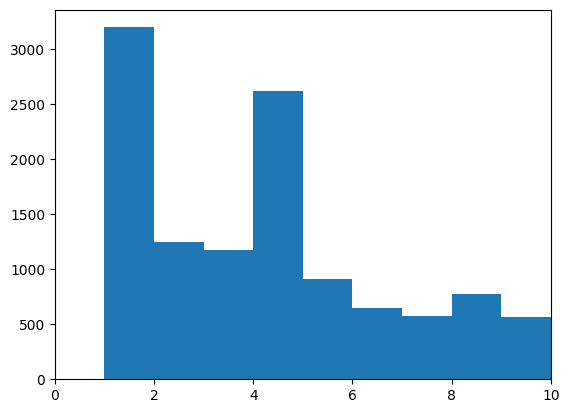

In [35]:
plt.hist(df_LastFYYear_Customer['Sector'], bins=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,25,50,100])
plt.xlim([0,10])

In [39]:
print(df_LastFYYear['Sector'].unique())
print(df_LastFYYear['SubCategory'].unique())

['Education' 'Local Government' 'Health' 'Not for Profit'
 'Central Government' 'Police' 'Wider Public Sector'
 'Devolved Administrations' 'Fire and Rescue' 'Unregistered or Unknown'
 'Private Sector' 'Other' 'Non UK Public Sector' 'Utility (Historic)']
['Payment Services' 'Learning and Development'
 'Temporary Staffing Non Clinical'
 'Vehicle Leasing, Fleet Management and Salary Sacrifice Car Schemes'
 'Hard, Soft and Total Facilities Management'
 'Consultancy and Audit Services' 'Office Supplies'
 'Purchase of Standard and Specialist Vehicles' 'Software'
 'Electricity and Gas' 'Cloud Services' 'Vehicle Hire Solutions' 'Travel'
 'Networks and Telecoms' 'Post and Courier' 'Hardware'
 'Temporary Staffing Clinical and Healthcare'
 'Construction Professional Services' 'Mobile' 'Employee Services'
 'Technology Managed Services' 'Permanent Recruitment' 'Insurance'
 'Contact Centres Service Provision' 'Bespoke Application Development'
 'Water and Wastewater' 'Low Value Procurements' 'Fuels'
